# AIMS AI Course - Homework 2


**Name:** Mahugnon Aime Loick Gohouede


## Problem  1

Design a smooth function $$\phi(\theta)$$ that pushes weights toward the quantization levels  
$$
\{-1,-0.5,0,0.5,1\}
$$

$$
\phi(\theta)
=
\frac{1}{4}
\Big[
\tanh\big(\alpha(\theta+3b)\big)
+
\tanh\big(\alpha(\theta+b)\big)
+
\tanh\big(\alpha(\theta-b)\big)
+
\tanh\big(\alpha(\theta-3b)\big)
\Big]
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)

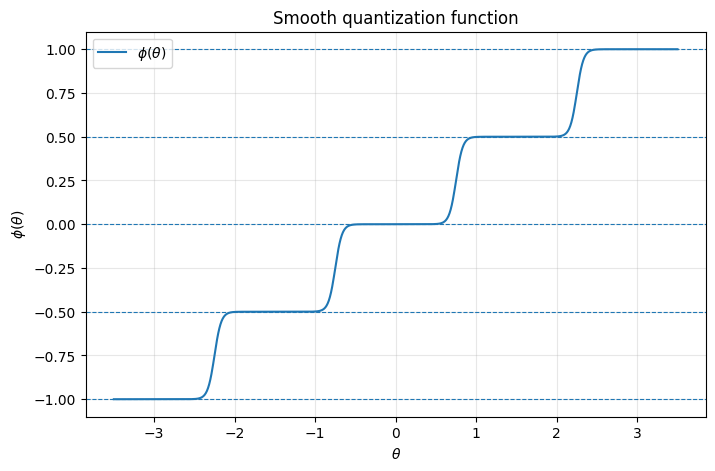

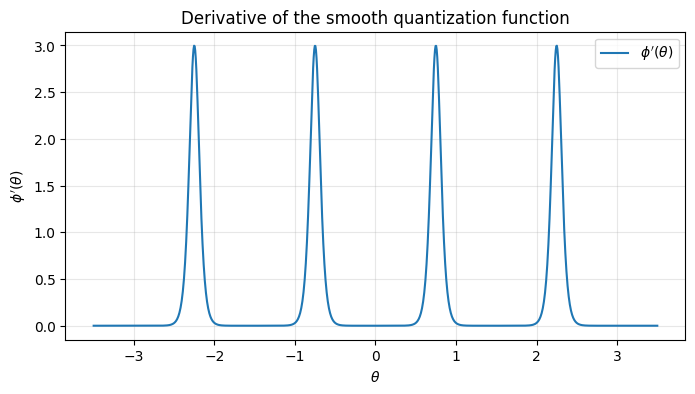

In [2]:

# Smooth quantization function with plateaus at {-1, -0.5, 0, 0.5, 1}
def phi(theta, alpha=12.0, b=0.75):
    """
    theta : scalar or numpy array
    alpha : controls steepness of transitions
    b     : transition locations at ±b and ±3b
            with b=0.75 gives transitions near -2.25, -0.75, 0.75, 2.25
    """
    return 0.25 * (
        np.tanh(alpha * (theta + 3*b)) +
        np.tanh(alpha * (theta + b)) +
        np.tanh(alpha * (theta - b)) +
        np.tanh(alpha * (theta - 3*b))
    )

# Derivative of phi, useful for the preconditioner
def phi_prime(theta, alpha=12.0, b=0.75):
    sech2 = lambda x: 1 / np.cosh(x)**2
    return 0.25 * alpha * (
        sech2(alpha * (theta + 3*b)) +
        sech2(alpha * (theta + b)) +
        sech2(alpha * (theta - b)) +
        sech2(alpha * (theta - 3*b))
    )

# Example plot
theta = np.linspace(-3.5, 3.5, 1000)
y = phi(theta)
dy = phi_prime(theta)

plt.figure(figsize=(8, 5))
plt.plot(theta, y, label=r'$\phi(\theta)$')
for level in [-1, -0.5, 0, 0.5, 1]:
    plt.axhline(level, linestyle='--', linewidth=0.8)
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\phi(\theta)$')
plt.title('Smooth quantization function')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(theta, dy, label=r"$\phi'(\theta)$")
plt.xlabel(r'$\theta$')
plt.ylabel(r"$\phi'(\theta)$")
plt.title('Derivative of the smooth quantization function')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Problem 3: Attention


---
## Part 1 — Verifying the weight construction

We define the attention mechanism and check that our chosen weights satisfy the requirements:
- $O > 0.9$ when query is $a$ and at least one $a$ is in the context
- $O \approx 0$ otherwise

In [4]:
# Token embeddings
a = np.array([[0], [1]], dtype=float)   # shape (2,1)
b = np.array([[1], [0]], dtype=float)

# Chosen weight matrices  (k=1, lambda=2)
lam = 2.0
Wk = lam * np.array([[-1, 1]])   # shape (1,2)
Wq = lam * np.array([[-1, 1]])   # shape (1,2)
Wv = np.array([[0, 1]])          # shape (1,2)

def attention(query, S, Wk, Wq, Wv):
    """
    Single-query attention.
    query : (2,1)
    S     : (2,N)  — context matrix
    Returns scalar output O.
    """
    Q = Wq @ query          # (1,1)
    K = Wk @ S              # (1,N)
    V = Wv @ S              # (1,N)
    logits = Q.T @ K        # (1,N)
    weights = np.exp(logits) / np.sum(np.exp(logits))  # softmax, shape (1,N)
    O = weights @ V.T       # (1,1)
    return float(O.flat[0])

In [5]:
# --- Test 1: query=a, context has exactly 1 'a' and N-1 'b's, for N=1..100 ---
N_values = range(1, 101)
outputs_query_a_m1 = []

for N in N_values:
    # Context: first token is 'a', rest are 'b'
    S = np.hstack([a] + [b] * (N - 1))   # (2, N)
    O = attention(a, S, Wk, Wq, Wv)
    outputs_query_a_m1.append(O)

# Worst case
worst = min(outputs_query_a_m1)
print(f"Worst-case O (query=a, m=1): {worst:.4f}  >0.9? {worst > 0.9}")

Worst-case O (query=a, m=1): 0.9679  >0.9? True


In [6]:
# --- Test 2: query=b, context has N-1 'a's and 1 'b', for N=1..100 ---
outputs_query_b = []
for N in N_values:
    S = np.hstack([a] * (N - 1) + [b])   # (2, N)
    O = attention(b, S, Wk, Wq, Wv)
    outputs_query_b.append(O)

worst_b = max(outputs_query_b)
print(f"Worst-case O (query=b): {worst_b:.6f}  <0.9? {worst_b < 0.9}")

Worst-case O (query=b): 0.032143  <0.9? True


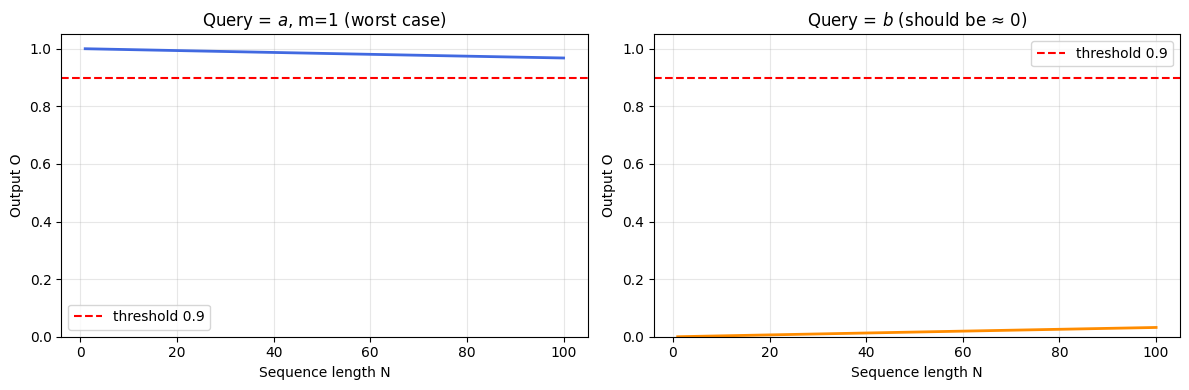

Figure saved.


In [7]:
# Plot: Output as a function of N (worst case: m=1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(N_values), outputs_query_a_m1, color='royalblue', lw=2)
axes[0].axhline(0.9, color='red', ls='--', label='threshold 0.9')
axes[0].set_xlabel('Sequence length N')
axes[0].set_ylabel('Output O')
axes[0].set_title('Query = $a$, m=1 (worst case)')
axes[0].legend()
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(N_values), outputs_query_b, color='darkorange', lw=2)
axes[1].axhline(0.9, color='red', ls='--', label='threshold 0.9')
axes[1].set_xlabel('Sequence length N')
axes[1].set_ylabel('Output O')
axes[1].set_title('Query = $b$ (should be ≈ 0)')
axes[1].legend()
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('part1_output_vs_N.png', dpi=150)
plt.show()
print("Figure saved.")

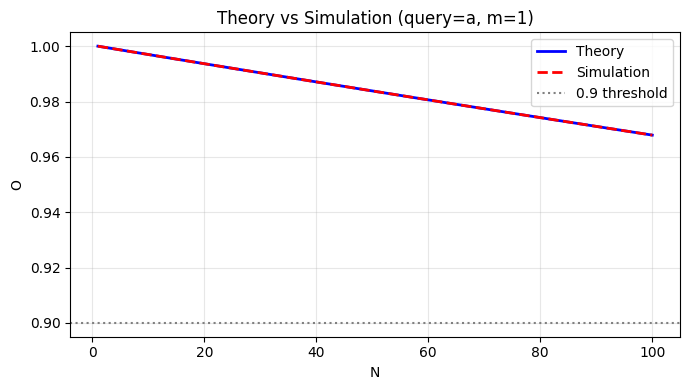

In [8]:
# --- Theoretical formula vs simulation ---
# O = m*exp(2*lam^2) / (m*exp(2*lam^2) + (N-m))
N_arr = np.arange(1, 101, dtype=float)
m = 1
theory = m * np.exp(2 * lam**2) / (m * np.exp(2 * lam**2) + (N_arr - m))
theory[0] = 1.0   # N=1, m=1: only one token (the 'a'), so O=1

plt.figure(figsize=(7, 4))
plt.plot(N_arr, theory, 'b-', lw=2, label='Theory')
plt.plot(list(N_values), outputs_query_a_m1, 'r--', lw=2, label='Simulation')
plt.axhline(0.9, color='gray', ls=':', label='0.9 threshold')
plt.xlabel('N'); plt.ylabel('O'); plt.title('Theory vs Simulation (query=a, m=1)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('part1_theory_vs_sim.png', dpi=150)
plt.show()

---
## Part 2 — Unlearning with short sequences ($N = 10$)

We now study gradient descent attempting to change the model output to $0.9$ for all queries of type $a$, using only sequences of length $N = 10$.

In [9]:
# Reimplement with PyTorch for gradient tracking

class SingleQueryAttention(nn.Module):
    def __init__(self, lam=2.0):
        super().__init__()
        # k=1, d=2
        self.Wk = nn.Parameter(torch.tensor([[-lam, lam]]))
        self.Wq = nn.Parameter(torch.tensor([[-lam, lam]]))
        self.Wv = nn.Parameter(torch.tensor([[0.0, 1.0]]))

    def forward(self, query, S):
        """
        query : (2, 1)
        S     : (2, N)
        """
        Q = self.Wq @ query        # (1,1)
        K = self.Wk @ S            # (1,N)
        V = self.Wv @ S            # (1,N)
        logits = Q.T @ K           # (1,N)
        weights = torch.softmax(logits, dim=-1)  # (1,N)
        return (weights @ V.T).squeeze()         # scalar

In [10]:
def make_sequence(m, N):
    """Sequence with m 'a' tokens and N-m 'b' tokens, query is 'a'."""
    a_t = torch.tensor([[0.0], [1.0]])
    b_t = torch.tensor([[1.0], [0.0]])
    tokens = [a_t] * m + [b_t] * (N - m)
    S = torch.cat(tokens, dim=1)   # (2, N)
    return a_t, S

N_train = 10
target   = torch.tensor(0.9)
model    = SingleQueryAttention(lam=2.0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training data: all possible m in {1,...,10} for N=10
train_data = [make_sequence(m, N_train) for m in range(1, N_train + 1)]

# Track gradient norms and loss
loss_history     = []
grad_Wk_history  = []
grad_Wq_history  = []
grad_Wv_history  = []

n_steps = 2000
for step in range(n_steps):
    optimizer.zero_grad()
    total_loss = torch.tensor(0.0)
    for query, S in train_data:
        O = model(query, S)
        total_loss = total_loss + (O - target) ** 2
    total_loss = total_loss / len(train_data)
    total_loss.backward()

    # Record gradient norms before stepping
    grad_Wk_history.append(model.Wk.grad.norm().item())
    grad_Wq_history.append(model.Wq.grad.norm().item())
    grad_Wv_history.append(model.Wv.grad.norm().item())
    loss_history.append(total_loss.item())

    optimizer.step()

print(f"Final loss: {loss_history[-1]:.6f}")
print(f"Wk: {model.Wk.data}")
print(f"Wq: {model.Wq.data}")
print(f"Wv: {model.Wv.data}")

Final loss: 0.000000
Wk: tensor([[-2.0371,  2.0371]])
Wq: tensor([[-2.0000,  2.0372]])
Wv: tensor([[0.0469, 0.9004]])


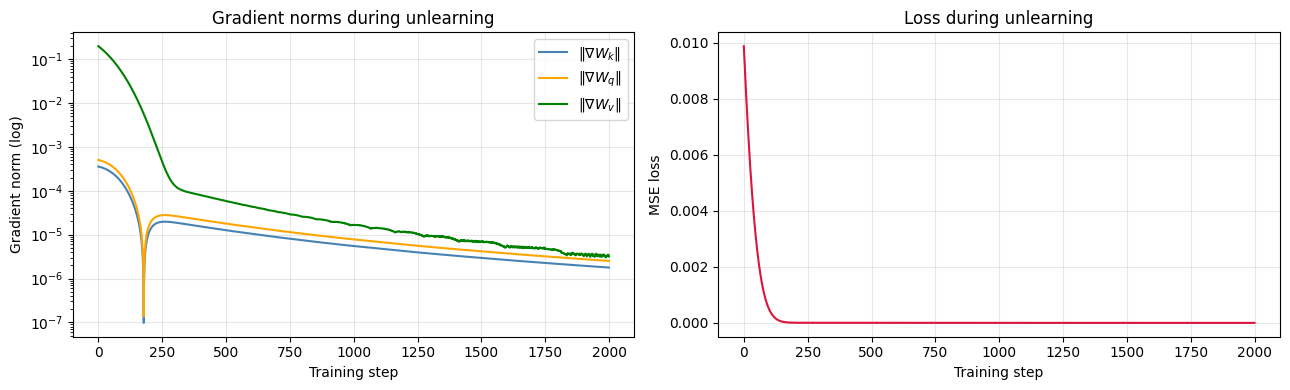

In [13]:
# Plot gradient norms across training
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogy(grad_Wk_history, label=r'$\|\nabla W_k\|$', color='steelblue')
axes[0].semilogy(grad_Wq_history, label=r'$\|\nabla W_q\|$', color='orange')
axes[0].semilogy(grad_Wv_history, label=r'$\|\nabla W_v\|$', color='green')
axes[0].set_xlabel('Training step'); axes[0].set_ylabel('Gradient norm (log)')
axes[0].set_title('Gradient norms during unlearning')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_history, color='crimson')
axes[1].set_xlabel('Training step'); axes[1].set_ylabel('MSE loss')
axes[1].set_title('Loss during unlearning')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('part2_gradients.png', dpi=150)
plt.show()

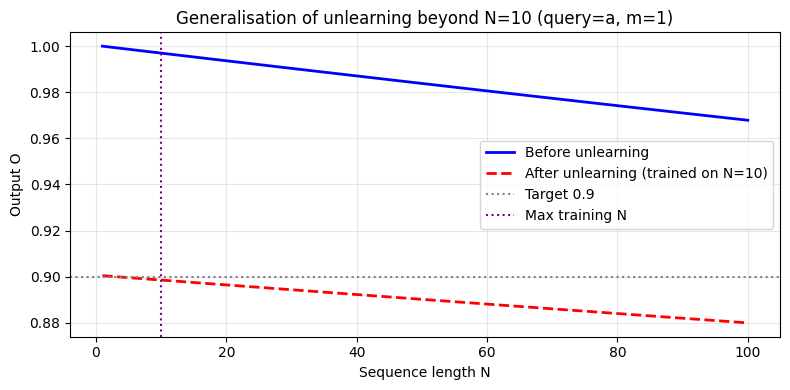

Output at N=10:  0.8985  (target: 0.9)
Output at N=50:  0.8901
Output at N=100: 0.8799


In [14]:
# --- Test generalisation: does the unlearned model work for N up to 100? ---
model.eval()
N_test_values = range(1, 101)
outputs_after = []

with torch.no_grad():
    for N in N_test_values:
        query, S = make_sequence(1, N)   # worst case: m=1
        O = model(query, S).item()
        outputs_after.append(O)

plt.figure(figsize=(8, 4))
plt.plot(list(N_values), outputs_query_a_m1, 'b-', lw=2, label='Before unlearning')
plt.plot(list(N_test_values), outputs_after, 'r--', lw=2, label='After unlearning (trained on N=10)')
plt.axhline(0.9, color='gray', ls=':', lw=1.5, label='Target 0.9')
plt.axvline(10, color='purple', ls=':', lw=1.5, label='Max training N')
plt.xlabel('Sequence length N')
plt.ylabel('Output O')
plt.title('Generalisation of unlearning beyond N=10 (query=a, m=1)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('part2_generalisation.png', dpi=150)
plt.show()

print(f"Output at N=10:  {outputs_after[9]:.4f}  (target: 0.9)")
print(f"Output at N=50:  {outputs_after[49]:.4f}")
print(f"Output at N=100: {outputs_after[99]:.4f}")

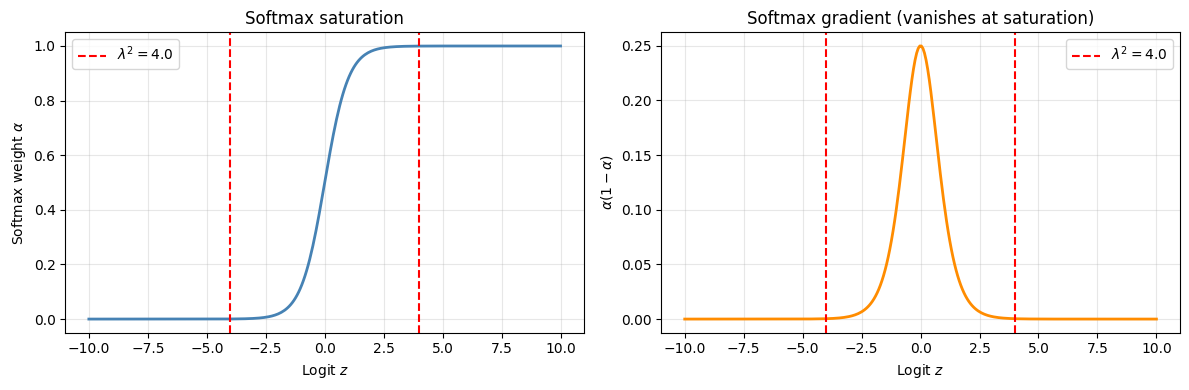

Gradient alpha*(1-alpha) at logit = lambda^2 = 4.0: 0.000336


In [15]:
# --- Visualise the softmax saturation: gradient of softmax vs logit magnitude ---
logits = np.linspace(-10, 10, 300)
# For a 2-token case: alpha = exp(z) / (exp(z) + exp(-z))
alpha = np.exp(logits) / (np.exp(logits) + np.exp(-logits))
grad_softmax = alpha * (1 - alpha)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(logits, alpha, color='steelblue', lw=2)
axes[0].axvline(lam**2, color='red', ls='--', label=f'$\\lambda^2={lam**2}$')
axes[0].axvline(-lam**2, color='red', ls='--')
axes[0].set_xlabel('Logit $z$'); axes[0].set_ylabel('Softmax weight $\\alpha$')
axes[0].set_title('Softmax saturation')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(logits, grad_softmax, color='darkorange', lw=2)
axes[1].axvline(lam**2, color='red', ls='--', label=f'$\\lambda^2={lam**2}$')
axes[1].axvline(-lam**2, color='red', ls='--')
axes[1].set_xlabel('Logit $z$'); axes[1].set_ylabel('$\\alpha(1-\\alpha)$')
axes[1].set_title('Softmax gradient (vanishes at saturation)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('part2_softmax_saturation.png', dpi=150)
plt.show()

val_at_lam2 = float(np.interp(lam**2, logits, grad_softmax))
print(f"Gradient alpha*(1-alpha) at logit = lambda^2 = {lam**2}: {val_at_lam2:.6f}")